# Analysis of Evaluation Results
### 1. Imports & global settings

In [6]:
import os
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Show more columns when inspecting data
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

sns.set(style="whitegrid")

# Where your evaluation CSVs are stored
EVALUATION_FOLDER = "evaluation"

### 2. Helper: parse experiment config from filename

In [7]:
def parse_filename(path: str):
    """
    Parse experiment configuration info and mode from an evaluation CSV filename.

    Expected patterns:
        <config>_RAG_evaluation.csv
        <config>_Direct_evaluation.csv

    Returns:
        {
            'config': str,       # base config name (anything before _RAG/_Direct)
            'mode': 'RAG'|'Direct',
            'raw_name': str      # base name without extension
        }
    """
    base = os.path.basename(path)
    # strip ".csv"
    base = base.replace(".csv", "")
    raw_name = base.replace("_evaluation", "")

    if raw_name.endswith("_RAG"):
        mode = "RAG"
        config = raw_name[:-4]  # remove "_RAG"
    elif raw_name.endswith("_Direct"):
        mode = "Direct"
        config = raw_name[:-7]  # remove "_Direct"
    else:
        # fallback if mode not encoded as expected
        mode = "Unknown"
        config = raw_name

    return {"config": config, "mode": mode, "raw_name": raw_name}

### 3. Load all evaluation CSVs into a single DataFrame

In [8]:
csv_files = glob(os.path.join(EVALUATION_FOLDER, "*.csv"))
print(f"Found {len(csv_files)} evaluation files.")

all_data = []

for path in csv_files:
    df = pd.read_csv(path)
    meta = parse_filename(path)

    df["config"] = meta["config"]
    df["mode"] = meta["mode"]
    df["file_name"] = os.path.basename(path)

    # Convert textual eval scores to numeric
    for col in ["eval_factuality", "eval_relevance", "eval_completeness", "eval_confidence"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Convert correctness to 0/1
    df["eval_correctness_numeric"] = df["eval_correctness"].apply(
        lambda x: 1 if str(x).strip().lower() == "correct" else 0
    )

    # If similarity_score is still the original string list (not the mean),
    # we can compute an average similarity here; otherwise we keep existing columns.
    if "mean_similarity_score" not in df.columns:
        def parse_similarity_list(x):
            # expect something like "[0.81, 0.72, ...]"
            s = str(x).strip()
            try:
                # very lightweight parser, safer than eval
                s = s.strip("[]")
                if not s:
                    return np.nan
                vals = [float(v) for v in s.split(",") if v.strip() != ""]
                return float(np.mean(vals)) if vals else np.nan
            except Exception:
                return np.nan

        df["mean_similarity_score"] = df["similarity_score"].apply(parse_similarity_list)

    all_data.append(df)

all_data = pd.concat(all_data, ignore_index=True)
print("Combined shape:", all_data.shape)
all_data.head()

Found 2 evaluation files.
Combined shape: (400, 18)


,question,generated_answer,true_answer,company,similarity_score,optimal_index,eval_factuality,eval_relevance,eval_completeness,eval_confidence,eval_correctness,eval_feedback,mean_similarity_score,max_similarity_score,config,mode,file_name,eval_correctness_numeric
0,What is the name of this agreement?,"The name of this agreement is ""INTELLECTUAL PR...",INTELLECTUAL PROPERTY RIGHTS AGREEMENT,RareElementResourcesLtd_20171019_SC 13D_EX-99....,"[0.684356749, 0.67988205, 0.671283722, 0.66886...",contracts-recursive-index,5,5,5,5,Correct,Feedback: The response accurately identifies t...,0.666805,0.684357,gemini-2.5-flash-testset,Direct,gemini-2.5-flash-testset_Direct_evaluation.csv,1
1,What is the name of this agreement?,"The name of this agreement is ""TECHNOLOGY OUTS...",TECHNOLOGY OUTSOURCING AGREEMENT,OFGBANCORP_03_28_2007-EX-10.23-OUTSOURCING AGR...,"[0.684356749, 0.67988205, 0.671283722, 0.66886...",contracts-recursive-index,5,5,5,5,Correct,Feedback: The response is factually correct an...,0.666805,0.684357,gemini-2.5-flash-testset,Direct,gemini-2.5-flash-testset_Direct_evaluation.csv,1
2,What is the name of this agreement?,The name of this agreement is the Form of Sub-...,FORM OF SUB-RESELLER AGREEMENT,SalesforcecomInc_20171122_10-Q_EX-10.1_1096153...,"[0.684356749, 0.67988205, 0.671283722, 0.66886...",contracts-recursive-index,4,5,4,5,Correct,Feedback: The response provides the name of th...,0.666805,0.684357,gemini-2.5-flash-testset,Direct,gemini-2.5-flash-testset_Direct_evaluation.csv,1
3,What is the name of this agreement?,"The name of this agreement is ""JOINT DEVELOPME...",JOINT DEVELOPMENT AGREEMENT,FuelcellEnergyInc_20191106_8-K_EX-10.1_1186800...,"[0.684356749, 0.67988205, 0.671283722, 0.66886...",contracts-recursive-index,5,5,5,5,Correct,Feedback: The response accurately identifies t...,0.666805,0.684357,gemini-2.5-flash-testset,Direct,gemini-2.5-flash-testset_Direct_evaluation.csv,1
4,What is the name of this agreement?,"The name of this agreement is the ""CO-BRANDING...",CO-BRANDING AGREEMENT,PcquoteComInc_19990721_S-1A_EX-10.11_6377149_E...,"[0.684356749, 0.67988205, 0.671283722, 0.66886...",contracts-recursive-index,5,5,5,5,Correct,Feedback: The response is completely factual b...,0.666805,0.684357,gemini-2.5-flash-testset,Direct,gemini-2.5-flash-testset_Direct_evaluation.csv,1


### 4. Derived metrics: overall score, etc.

In [9]:
# Overall LLM-based quality score: average of 4 rubrics
score_cols = ["eval_factuality", "eval_relevance", "eval_completeness", "eval_confidence"]
all_data["overall_score"] = all_data[score_cols].mean(axis=1)

# Basic sanity statistics
print("\n=== Global stats ===")
print(all_data[score_cols + ["overall_score", "eval_correctness_numeric", "mean_similarity_score"]].describe())

print("\nMode distribution:")
print(all_data["mode"].value_counts())

print("\nConfigs (top 20 by count):")
print(all_data["config"].value_counts().head(20))


=== Global stats ===
       eval_factuality  eval_relevance  eval_completeness  eval_confidence  overall_score  eval_correctness_numeric  mean_similarity_score
count       400.000000      400.000000         400.000000       400.000000     400.000000                400.000000             400.000000
mean          2.952500        4.552500           2.890000         3.920000       3.578750                  0.392500               0.558558
std           1.810646        1.002375           1.668791         1.465937       1.228085                  0.488919               0.083933
min           1.000000        1.000000           1.000000         1.000000       1.000000                  0.000000               0.343819
25%           1.000000        5.000000           1.000000         3.000000       2.500000                  0.000000               0.504111
50%           3.000000        5.000000           3.000000         5.000000       3.750000                  0.000000               0.551821
75%  

### 5. Compare RAG vs Direct globally

In [10]:
agg_mode = (
    all_data
    .groupby("mode")
    .agg(
        mean_factuality=("eval_factuality", "mean"),
        mean_relevance=("eval_relevance", "mean"),
        mean_completeness=("eval_completeness", "mean"),
        mean_confidence=("eval_confidence", "mean"),
        mean_overall_score=("overall_score", "mean"),
        mean_correctness=("eval_correctness_numeric", "mean"),
        mean_similarity=("mean_similarity_score", "mean"),
        n=("question", "count"),
    )
)

print("\n=== Global RAG vs Direct comparison ===")
display(agg_mode)


=== Global RAG vs Direct comparison ===


,mean_factuality,mean_relevance,mean_completeness,mean_confidence,mean_overall_score,mean_correctness,mean_similarity,n
mode,,,,,,,,
Direct,2.660,4.625,2.605,3.68,3.3925,0.320,0.558558,200
RAG,3.245,4.480,3.175,4.16,3.7650,0.465,0.558558,200


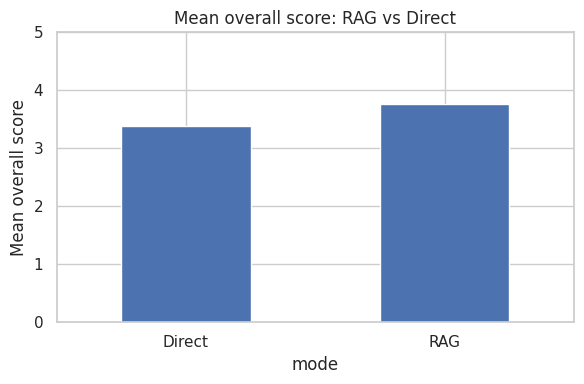

In [11]:
# Simple bar plot: overall score RAG vs Direct
plt.figure(figsize=(6, 4))
agg_mode["mean_overall_score"].plot(kind="bar")
plt.ylabel("Mean overall score")
plt.title("Mean overall score: RAG vs Direct")
plt.ylim(0, 5)  # scores are between 1-5
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 6. Config-level analysis

In [12]:
# Aggregate per (config, mode)
agg_config = (
    all_data
    .groupby(["config", "mode"])
    .agg(
        mean_factuality=("eval_factuality", "mean"),
        mean_relevance=("eval_relevance", "mean"),
        mean_completeness=("eval_completeness", "mean"),
        mean_confidence=("eval_confidence", "mean"),
        mean_overall_score=("overall_score", "mean"),
        mean_correctness=("eval_correctness_numeric", "mean"),
        mean_similarity=("mean_similarity_score", "mean"),
        n=("question", "count"),
    )
    .reset_index()
)

print("\n=== Config-level summary (first 20 rows) ===")
agg_config.head(20)


=== Config-level summary (first 20 rows) ===


,config,mode,mean_factuality,mean_relevance,mean_completeness,mean_confidence,mean_overall_score,mean_correctness,mean_similarity,n
0,gemini-2.5-flash-testset,Direct,2.660,4.625,2.605,3.68,3.3925,0.320,0.558558,200
1,gemini-2.5-flash-testset,RAG,3.245,4.480,3.175,4.16,3.7650,0.465,0.558558,200


In [13]:
# Identify best/worst configs by overall score (RAG only)
rag_configs = agg_config[agg_config["mode"] == "RAG"].copy()
rag_top = rag_configs.sort_values("mean_overall_score", ascending=False).head(10)
rag_bottom = rag_configs.sort_values("mean_overall_score", ascending=True).head(10)

print("\nTop 10 RAG configs by mean overall score:")
display(rag_top[["config", "mean_overall_score", "mean_correctness", "mean_similarity", "n"]])

print("\nBottom 10 RAG configs by mean overall score:")
display(rag_bottom[["config", "mean_overall_score", "mean_correctness", "mean_similarity", "n"]])


Top 10 RAG configs by mean overall score:


,config,mean_overall_score,mean_correctness,mean_similarity,n
1,gemini-2.5-flash-testset,3.765,0.465,0.558558,200



Bottom 10 RAG configs by mean overall score:


,config,mean_overall_score,mean_correctness,mean_similarity,n
1,gemini-2.5-flash-testset,3.765,0.465,0.558558,200


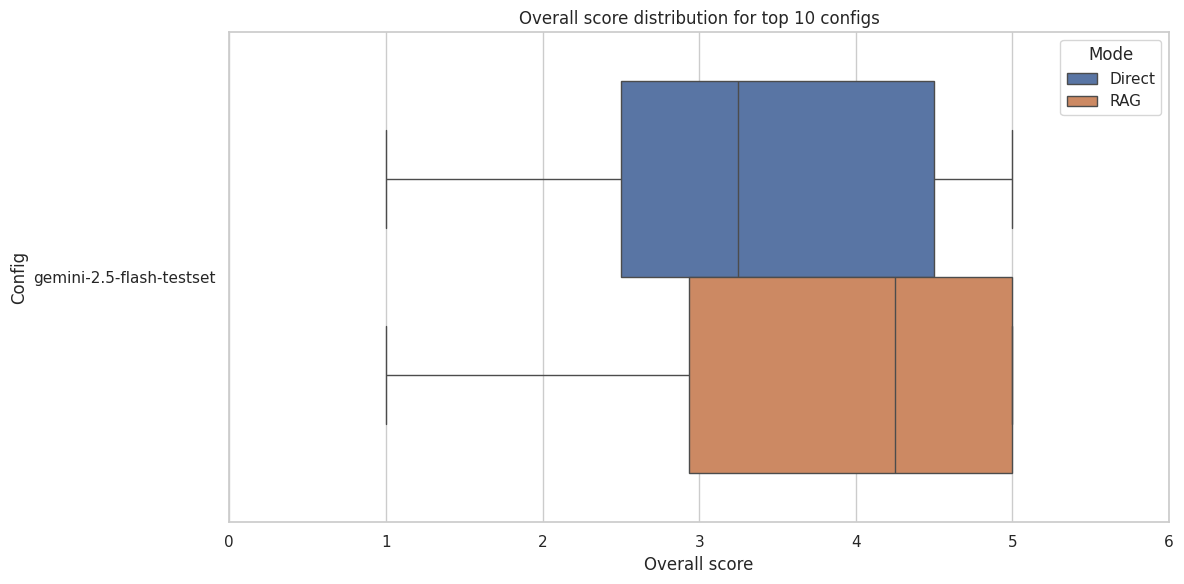

In [17]:
# Boxplot: overall score by (config, mode) for the most common configs
# (you can adjust 'top_k' if you have many configs)

top_k = 10
top_configs = (
    all_data["config"]
    .value_counts()
    .head(top_k)
    .index
    .tolist()
)

plot_data = all_data[all_data["config"].isin(top_configs)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_data,
    x="overall_score",
    y="config",
    hue="mode",
)
plt.xlim(0, 6)
plt.title(f"Overall score distribution for top {top_k} configs")
plt.xlabel("Overall score")
plt.ylabel("Config")
plt.legend(title="Mode")
plt.tight_layout()
plt.show()


### 7. Filename-level analysis (optional)


=== Company-level summary (first 20 rows) ===


,company,mode,mean_overall_score,mean_correctness,mean_similarity,n
0,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Direct,3.500000,0.000000,0.518442,2
1,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,RAG,3.750000,0.500000,0.518442,2
2,"ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING...",Direct,3.000000,0.000000,0.486577,1
3,"ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING...",RAG,2.500000,0.000000,0.486577,1
4,AimmuneTherapeuticsInc_20200205_8-K_EX-10.3_11...,Direct,3.500000,0.500000,0.615024,2
5,AimmuneTherapeuticsInc_20200205_8-K_EX-10.3_11...,RAG,5.000000,1.000000,0.615024,2
6,"BERKELEYLIGHTS,INC_06_26_2020-EX-10.12-COLLABO...",Direct,3.250000,0.000000,0.568647,1
7,"BERKELEYLIGHTS,INC_06_26_2020-EX-10.12-COLLABO...",RAG,4.500000,1.000000,0.568647,1
8,BIOAMBERINC_04_10_2013-EX-10.34-DEVELOPMENT AG...,Direct,4.500000,1.000000,0.640340,1
9,BIOAMBERINC_04_10_2013-EX-10.34-DEVELOPMENT AG...,RAG,4.750000,1.000000,0.640340,1


/tmp/ipykernel_9062/2566401427.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


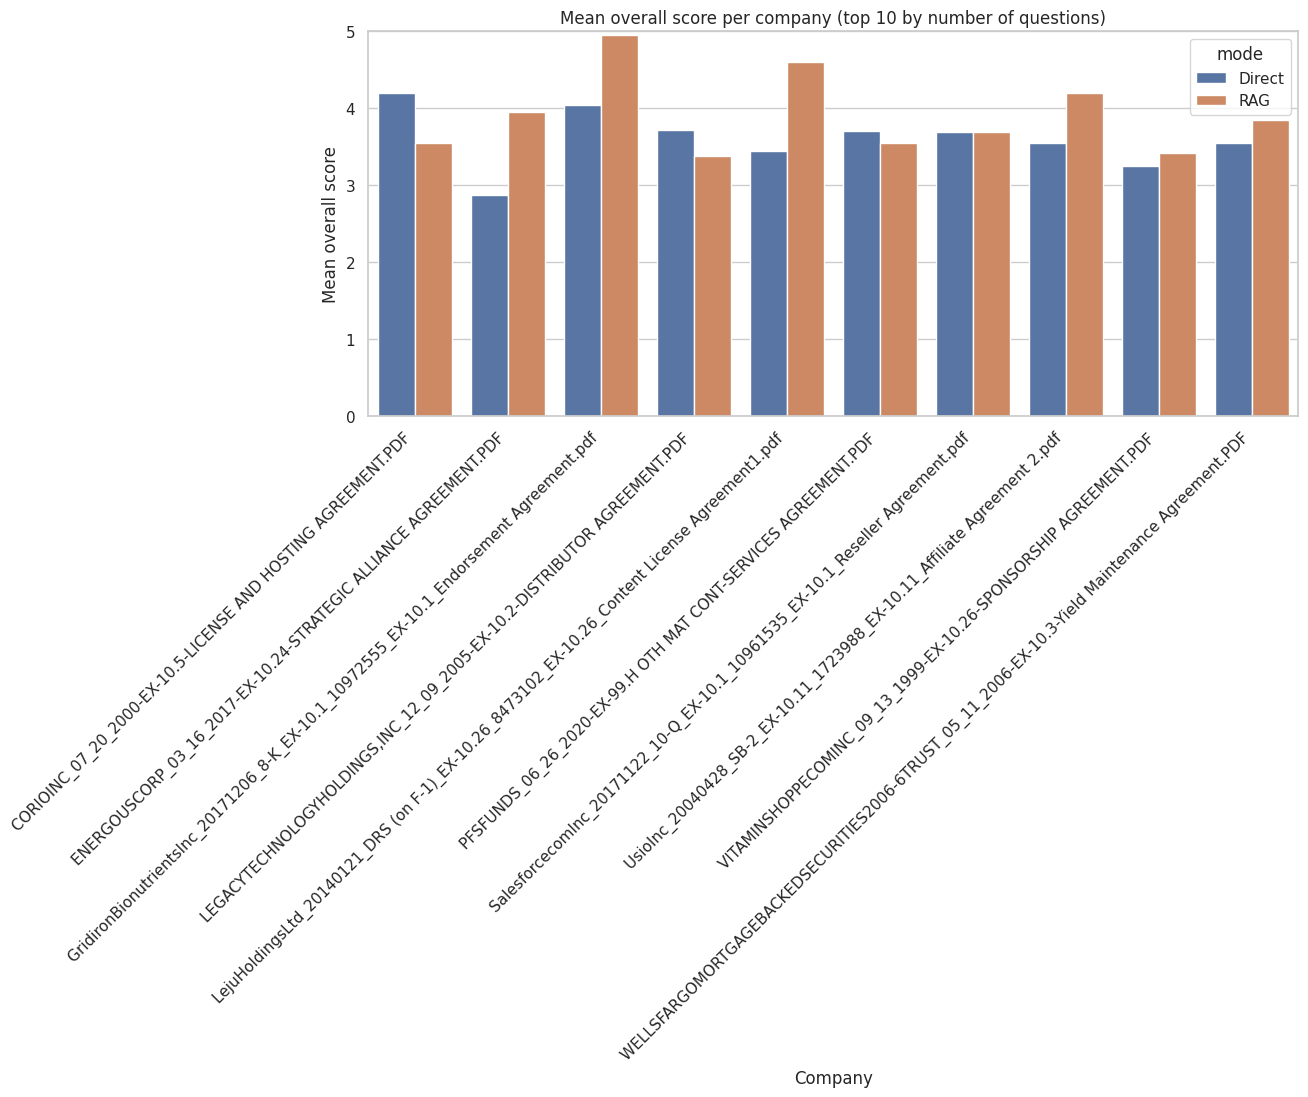

In [ ]:
if "filename" in all_data.columns:
    agg_filename_mode = (
        all_data
        .groupby(["filename", "mode"])
        .agg(
            mean_overall_score=("overall_score", "mean"),
            mean_correctness=("eval_correctness_numeric", "mean"),
            mean_similarity=("mean_similarity_score", "mean"),
            n=("question", "count"),
        )
        .reset_index()
    )

    print("\n=== Filename-level summary (first 20 rows) ===")
    display(agg_filename_mode.head(20))

    # Plot filename-level overall score for RAG vs Direct (top N filenames by size)
    top_filenames = (
        all_data["filename"]
        .value_counts()
        .head(10)
        .index
        .tolist()
    )

    filename_plot = agg_filename_mode[agg_filename_mode["filename"].isin(top_filenames)]

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=filename_plot,
        x="filename",
        y="mean_overall_score",
        hue="mode",
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 5)
    plt.title("Mean overall score per filename (top 10 by number of questions)")
    plt.ylabel("Mean overall score")
    plt.xlabel("Filename")
    plt.tight_layout()
    plt.show()


### 8. Relationship between similarity and LLM evaluation

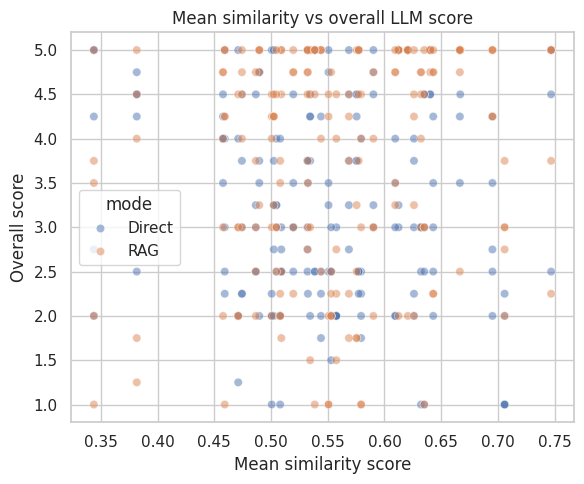


Correlation matrix (numeric columns):


,mean_similarity_score,eval_factuality,eval_relevance,eval_completeness,eval_confidence,overall_score,eval_correctness_numeric
mean_similarity_score,1.000000,0.066844,0.053517,0.116376,0.115962,0.109698,0.071957
eval_factuality,0.066844,1.000000,0.287915,0.909006,0.601928,0.915770,0.836473
eval_relevance,0.053517,0.287915,1.000000,0.349565,0.330344,0.527508,0.262131
eval_completeness,0.116376,0.909006,0.349565,1.000000,0.621336,0.931514,0.827136
eval_confidence,0.115962,0.601928,0.330344,0.621336,1.000000,0.798768,0.508999
overall_score,0.109698,0.915770,0.527508,0.931514,0.798768,1.000000,0.794690
eval_correctness_numeric,0.071957,0.836473,0.262131,0.827136,0.508999,0.794690,1.000000


In [19]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=all_data,
    x="mean_similarity_score",
    y="overall_score",
    hue="mode",
    alpha=0.5,
)
plt.title("Mean similarity vs overall LLM score")
plt.xlabel("Mean similarity score")
plt.ylabel("Overall score")
plt.tight_layout()
plt.show()

# Correlations
corr_cols = ["mean_similarity_score", "eval_factuality", "eval_relevance",
             "eval_completeness", "eval_confidence", "overall_score",
             "eval_correctness_numeric"]
print("\nCorrelation matrix (numeric columns):")
display(all_data[corr_cols].corr())

### 9. Simple LaTeX-style table: RAG vs Direct per config

In [20]:
# Pivot to get RAG and Direct side-by-side per config
pivot = agg_config.pivot(
    index="config",
    columns="mode",
    values="mean_overall_score",
)

# Keep only configs that have both modes
pivot = pivot.dropna(subset=["RAG", "Direct"], how="any")
pivot["Diff_RAG_minus_Direct"] = pivot["RAG"] - pivot["Direct"]

print("\n=== Config-level RAG vs Direct (mean overall score) ===")
display(pivot.sort_values("Diff_RAG_minus_Direct", ascending=False).head(20))

# Rough LaTeX rows (you can refine formatting for your paper)
print("\nLaTeX-style table rows (config, RAG, Direct, Diff):\n")
for cfg, row in pivot.iterrows():
    print(f"{cfg} & {row['RAG']:.3f} & {row['Direct']:.3f} & {row['Diff_RAG_minus_Direct']:.3f} \\\\")


=== Config-level RAG vs Direct (mean overall score) ===


mode,Direct,RAG,Diff_RAG_minus_Direct
config,,,
gemini-2.5-flash-testset,3.3925,3.765,0.3725



LaTeX-style table rows (config, RAG, Direct, Diff):

gemini-2.5-flash-testset & 3.765 & 3.393 & 0.373 \\


### 10. (Optional) Export aggregated tables for further reporting

In [ ]:
OUT_DIR = "evaluation_analysis_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

agg_mode.to_csv(os.path.join(OUT_DIR, "agg_mode_global.csv"))
agg_config.to_csv(os.path.join(OUT_DIR, "agg_config.csv"), index=False)

if "filename" in all_data.columns:
    agg_filename_mode.to_csv(os.path.join(OUT_DIR, "agg_filename_mode.csv"), index=False)

pivot.to_csv(os.path.join(OUT_DIR, "config_rag_vs_direct_overall_score.csv"))
print(f"\n[OK] Saved aggregated tables to: {OUT_DIR}/")


[OK] Saved aggregated tables to: evaluation_analysis_outputs/
